In [1]:
import Pkg
Pkg.activate("/home/matteo/Projects/OU_inference/")

  Activating project at `~/Projects/OU_inference`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, LinearAlgebra, PyPlot

Precompiling DiffusionEvolution
  ✓ Bzip2_jll
  ✓ CodecBzip2
  ✓ Zygote → ZygoteDistancesExt
  ✓ Flux
  ✓ MathOptInterface
  ✓ Optim → OptimMOIExt
  ✓ NLopt
  ✓ DiffusionEvolution
  8 dependencies successfully precompiled in 66 seconds. 171 already precompiled.


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x,y,d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [6]:
d = 10
nsamples = 1000
T = 50

50

In [14]:
β = 0.5

0.5

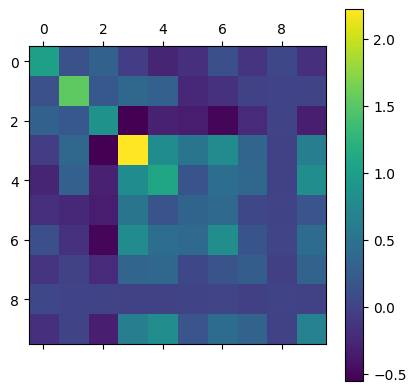

PyObject <matplotlib.colorbar.Colorbar object at 0x7f9ea49d4820>

In [15]:
m = UpperTriangular(randn(d,d))
J = (m * m') * (β/sqrt(d))
matshow(J)
colorbar()

In [16]:
θ = randn(d)
θ ./= norm(θ)
θ .*= 10*d

10-element Vector{Float64}:
  34.35485867910225
 -20.250817723557372
   5.0187672129355505
 -21.35691120307769
 -52.16753997971839
 -38.40159590360695
  18.98392233685865
 -33.74628860283189
 -14.56834871442376
 -44.952969920689235

In [23]:
γ = 0.01

0.01

In [24]:
x_sim = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T, err_sym=1e-6);

Σ has been symmetrized


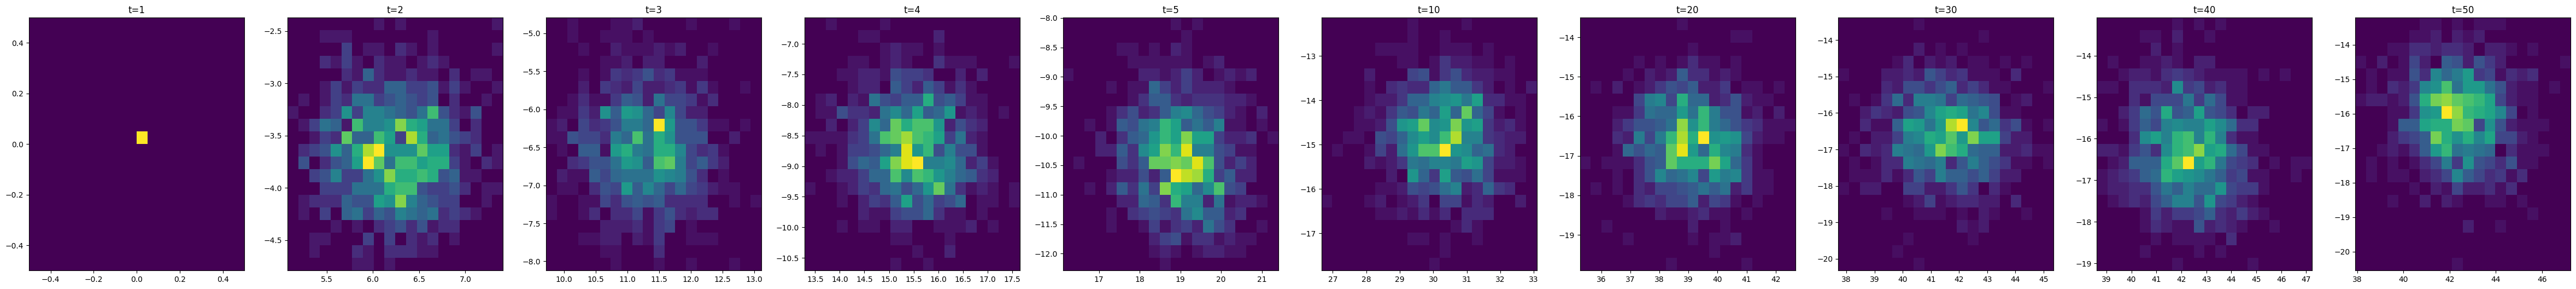

In [25]:
t_view = [1,2,3,4,5,10,20,30,40,50]
fig, ax =subplots(1, length(t_view), 6)
for i in eachindex(t_view)
    ax[i].hist2d(x_sim[1,:,t_view[i]], x_sim[2,:,t_view[i]], bins=20)
    ax[i].set_title("t=$(t_view[i])")
end

In [26]:
t_sample = [1,3,5,10]

4-element Vector{Int64}:
  1
  3
  5
 10

# Single thread

In [27]:
data = collect_data(zeros(d), x_sim[:,:,t_sample .+ 1], fill(1.0, nsamples, length(t_sample)), t_sample)

Data([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], DiffusionEvolution.Sample[DiffusionEvolution.Sample([6.652436630736101 6.66831207621504 … 5.904299554330382 6.7718521955975435; -3.257476279548844 -3.7072286249821307 … -3.1762676948905706 -4.112430437656623; … ; 0.053839425554070564 0.4812703143169661 … 0.4150906458292511 0.29184891921825934; -8.914213450168853 -9.360537347153818 … -8.868895535839648 -9.251220611243507], [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001  …  0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001]), DiffusionEvolution.Sample([16.10736192479514 16.201707400806555 … 15.461426066044755 17.004930615972622; -8.34236448192883 -7.8744645256491665 … -7.616020043821768 -9.89068642079457; … ; 0.8401420850105612 0.5100717322997791 … 0.43973480319866065 0.8162518822739872; -18.952119614754203 -19.895446769358564 … -20.01436048344882 -20.100419161896326], [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001  …

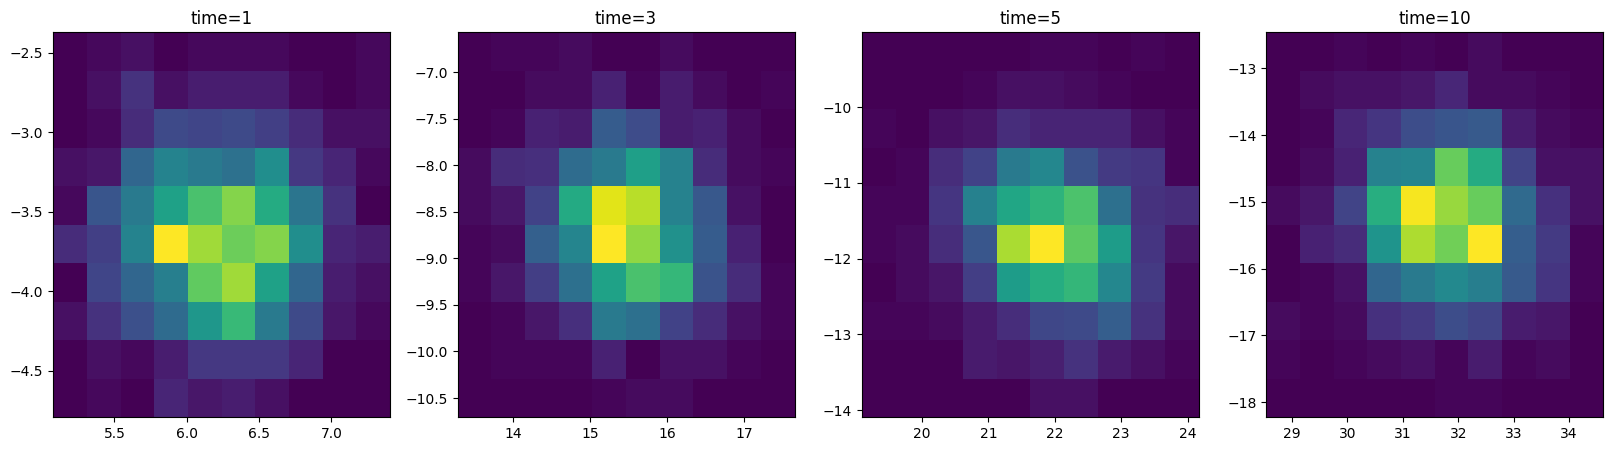

In [28]:
fig, ax = subplots(1, length(data.time), 5)
for i in eachindex(data.time)
    ax[i].hist2d(data.round[i].x[1,:], data.round[i].x[2,:], weights=data.round[i].w)
    ax[i].set_title("time=$(data.time[i])")
end

In [ ]:
lambda = 0.1
prior_J = 0.0
prior_theta = 0.0
epsilon = 1e-7
f_tol = 1e-5
x_tol = 1e-5
g_tol = 1e-3

In [ ]:
results = line_search_optimization(data, initialize=length(data.round), n_points=50, iterations =15,
    gamma_upper = 1.0, gamma_lower=0.01,
    lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, epsilon=epsilon,
    f_tol=f_tol, g_tol=g_tol, x_tol=x_tol)

In [ ]:
plot(results[2])

In [ ]:
teacher_ene = compute_energy(data.round[end].x, J, θ)
student_ene = compute_energy(data.round[end].x, results[1][end].minimizer, epsilon);

In [ ]:
scatter(teacher_ene, student_ene)

In [41]:
lambda = 0.01
prior_J = 0.0
prior_theta = 0.0
prior_gamma = 0.0
epsilon = 1e-6
eps_conv = 1e-5

1.0e-5

In [42]:
opt_results_gamma = learn_gamma_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, prior_gamma=prior_gamma, epsilon=epsilon)

(minf = 1712.9253307926354, minx = [1.0832918118199966, 0.04993465850591811, 1.2695330304089265, 0.12352458221481454, 0.08672705854257018, 0.993128519222423, -0.005353643387463396, 0.12689068572209578, -0.16466223334181074, 1.4529736508617943  …  -15.265423765494614, 11.853047031892023, -29.247751490161402, -44.67558502013949, -5.965968148028801, -6.199702679446114, -17.228203916920997, 2.2008054468331477, -32.34504560846751, 0.1], status = :FAILURE, nevals = 12, x_start = [1.0832918118199966, 0.04993465850591811, 1.2695330304089265, 0.12352458221481454, 0.08672705854257018, 0.993128519222423, -0.005353643387463396, 0.12689068572209578, -0.16466223334181074, 1.4529736508617943  …  -15.265423765494614, 11.853047031892023, -29.247751490161402, -44.67558502013949, -5.965968148028801, -6.199702679446114, -17.228203916920997, 2.2008054468331477, -32.34504560846751, 0.1])

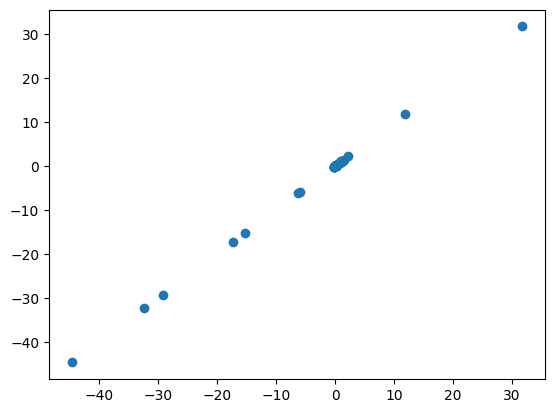

PyObject <matplotlib.collections.PathCollection object at 0x7f9e3638c4c0>

In [43]:
scatter(opt_results_gamma.x_start, opt_results_gamma.minx)

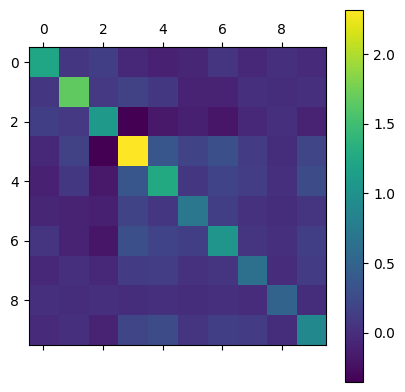

PyObject <matplotlib.colorbar.Colorbar object at 0x7f9e379c63e0>

In [40]:
de.compute_J(opt_results_gamma.x_start, d, epsilon) |> matshow |> colorbar

In [ ]:
opt_results_gamma.minx[end]

In [31]:
de.log_likelihood_gamma(opt_results_gamma.x_start, data, lambda, prior_J, prior_theta, prior_gamma, epsilon)

10215.651360500791

In [37]:
g_x = zeros(de.npars_gamma(d))
de.optim_wrapper_gamma(opt_results_gamma.x_start, g_x, data, lambda, prior_J, prior_theta, prior_gamma, epsilon)

1475.8986237749998

In [33]:
de.compute_parameters(opt_results_gamma.x_start, 1, data.x0, d, epsilon, lambda)

([0.31888367441988275, 0.0664555120939525, 0.8381810699866303, -1.4178611578515865, -1.0319444022312587, -0.32088714937946466, -0.4100292461907977, -0.30965679697735793, 0.0212345733132207, -3.234504397548286e-6], [0.2792664415260431 -0.00012715993756386295 … -5.414319060842443e-6 0.0; -0.0001271599374224386 0.27910095637784577 … 8.068796844298842e-7 0.0; … ; -5.414374241752285e-6 8.069116127273901e-7 … 0.27999860588201675 0.0; 0.0 0.0 … 0.0 0.2799999819196429])

In [ ]:
opt_results = learn_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, prior_x=prior_x, lambda=lambda, epsilon=epsilon, gamma=γ)

In [ ]:
J_inf = de.compute_J(x, d, epsilon)
matshow(J_inf)
colorbar()

In [ ]:
teacher_ene = compute_energy(data.round[end].x, J, θ)
student_ene = compute_energy(data.round[end].x, opt_results_gamma.minx, epsilon);

In [ ]:
scatter(teacher_ene, student_ene)

In [ ]:
fig, ax = subplots(1,3,6)
ax[1].scatter(opt_results_gamma.x_start, opt_results_gamma.minx)
ax[2].scatter(opt_results.x_start, opt_results.minx)
ax[3].scatter(opt_results_gamma.minx[1:end-1], opt_results.minx)

In [ ]:
gamma_grid = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0]
ll_val = zeros(length(gamma_grid))
for i in eachindex(gamma_grid)
    r = learn_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
        ftol_rel=eps_conv, prior_x=prior_x, epsilon=epsilon, γ=gamma_grid[i])
    ll_val[i] = r.minf
end

In [ ]:
plot(gamma_grid, ll_val, linestyle="dashed", marker="o")
yscale(:log)
xlabel("gamma")
ylabel("optimal log-likelihood");

In [ ]:
ll_val_gamma = [de.log_likelihood(opt_results_gamma.minx, data, γ, lambda, 0.0, 0.0, epsilon) for γ in gamma_grid]

In [ ]:
plot(gamma_grid, ll_val_gamma, linestyle="dashed", marker="o")
xlabel("gamma")
ylabel("log-likelihood")
yscale(:log)

In [ ]:
de.learn_nlopt_only_gamma(data, x0=opt_results.minx, xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, lambda=lambda, prior_gamma=0.0, epsilon=epsilon) 

In [ ]:
r = de.maximize(data; initialize=0, γ=0.1, xtol_rel=eps_conv, 
    ftol_rel=eps_conv, xtol_abs=eps_conv, ftol_abs=eps_conv, maxtime=-1, maxeval=-1, lambda=lambda,
    prior_x=prior_x, prior_gamma=prior_gamma, epsilon=epsilon, iterations=20);

In [ ]:
r.minγ

In [ ]:
plot(r.ll_iter)
yscale(:log)

In [ ]:
b=de.form_batches(250,30)

In [ ]:
unique(vcat(b...)) |> extrema

In [45]:
opt_results_gamma = learn_gamma_optim(data; initialize=length(t_sample), f_tol=eps_conv, x_tol=eps_conv, g_tol=eps_conv,
    lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, prior_gamma=prior_gamma, epsilon=epsilon)

 * Status: failure

 * Candidate solution
    Final objective value:     8.710291e+01

 * Found with
    Algorithm:     Fminbox with L-BFGS

 * Convergence measures
    |x - x'|               = 3.99e-06 ≤ 1.0e-05
    |x - x'|/|x'|          = 4.71e-08 ≰ 0.0e+00
    |f(x) - f(x')|         = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 0.00e+00 ≤ 1.0e-05
    |g(x)|                 = 4.18e-01 ≰ 1.0e-05

 * Work counters
    Seconds run:   25  (vs limit Inf)
    Iterations:    1000
    f(x) calls:    4571
    ∇f(x) calls:   4571


In [46]:
teacher_ene = compute_energy(data.round[end].x, J, θ)
student_ene = compute_energy(data.round[end].x, opt_results_gamma.minimizer, epsilon);

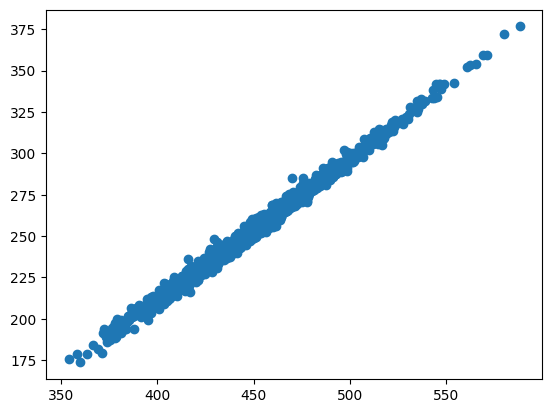

PyObject <matplotlib.collections.PathCollection object at 0x7f9e356107f0>

In [47]:
scatter(teacher_ene, student_ene)

# Multithread

In [ ]:
lambda = 0.01
prior_x = 0.01
prior_gamma = 0.01
epsilon = 1e-6
eps_conv = 1e-5

In [ ]:
d_val = [3,5,7,10]

In [ ]:
Threads.@threads for i in eachindex(d_val)
    f = "logs/opt_d$(d_val[i]).txt"
    data = collect_data(zeros(d_val[i]), x_sim[1:d_val[i],:,t_sample], fill(1.0, nsamples, length(t_sample)), t_sample)
    r = iterative_maximization(data; initialize=0, gamma=0.1, xtol_rel=eps_conv, 
        ftol_rel=eps_conv, xtol_abs=eps_conv, ftol_abs=eps_conv, lambda=lambda,
        prior_x=prior_x, prior_gamma=prior_gamma, epsilon=epsilon, iterations=5, logfile=f)
end